## Object detection API - From TensorFlow

In [3]:
!git clone --depth 1 git@github.com:tensorflow/models.git

fatal: destination path 'models' already exists and is not an empty directory.


### Object detection API: Imports & Usage

- `label_map_util` - This stores labels mapped to integer category and saves us from writing a lot of code (pbtxt format)

In [4]:
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.utils import ops as utils_ops

In [5]:
# Imports
import ipywidgets as widgets
from IPython.display import display

import os
import pathlib

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

import io
import scipy.misc
import numpy as np
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
from six.moves.urllib.request import urlopen

import tensorflow as tf
import tensorflow_hub as hub

tf.get_logger().setLevel('ERROR')

/var/folders/f2/j66wx7px7sx9qrws63ymk_sr0000gn/T/ipykernel_25089/2035802304.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


### Utilities

- Helper method to load an image
- Map of model names to TF Hub handle
- List of tuples with Human Keypoints for the COCO 2017 dataset. This is needed for models with keypoints.

In [39]:
def load_image_into_numpy_array(path):
    # Load an image from file to numpy array
    image = None
    if (path.startswith('http')):
        response = urlopen(path)
        image_data = response.read()
        image_data = BytesIO(image_data)
        image = Image.open(image_data)
    else:
        image_data = tf.io.gfile.GFile(path, 'rb').read()
        image = Image.open(BytesIO(image_data))

    (im_width, im_height) = image.size
    return np.array(image.getdata()).reshape(1, im_height, im_width, 3).astype(np.uint8)

ALL_MODELS = {
'CenterNet HourGlass104 512x512' : 'https://tfhub.dev/tensorflow/centernet/hourglass_512x512/1',
'CenterNet HourGlass104 Keypoints 512x512': 'https://tfhub.dev/tensorflow/centernet/hourglass_512x512_kpts/1',
'CenterNet HourGlass104 1024x1024' : 'https://tfhub.dev/tensorflow/centernet/hourglass_1024x1024/1',
'CenterNet HourGlass104 Keypoints 1024x1024' : 'https://tfhub.dev/tensorflow/centernet/hourglass_1024x1024_kpts/1',
'CenterNet Resnet50 V1 FPN 512x512' : 'https://tfhub.dev/tensorflow/centernet/resnet50v1_fpn_512x512/1',
'CenterNet Resnet50 V1 FPN Keypoints 512x512' : 'https://tfhub.dev/tensorflow/centernet/resnet50v1_fpn_512x512_kpts/1',
'CenterNet Resnet101 V1 FPN 512x512' : 'https://tfhub.dev/tensorflow/centernet/resnet101v1_fpn_512x512/1',
'CenterNet Resnet50 V2 512x512' : 'https://tfhub.dev/tensorflow/centernet/resnet50v2_512x512/1',
'CenterNet Resnet50 V2 Keypoints 512x512' : 'https://tfhub.dev/tensorflow/centernet/resnet50v2_512x512_kpts/1',
'EfficientDet D0 512x512' : 'https://tfhub.dev/tensorflow/efficientdet/d0/1',
'EfficientDet D1 640x640' : 'https://tfhub.dev/tensorflow/efficientdet/d1/1',
'EfficientDet D2 768x768' : 'https://tfhub.dev/tensorflow/efficientdet/d2/1',
'EfficientDet D3 896x896' : 'https://tfhub.dev/tensorflow/efficientdet/d3/1',
'EfficientDet D4 1024x1024' : 'https://tfhub.dev/tensorflow/efficientdet/d4/1',
'EfficientDet D5 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d5/1',
'EfficientDet D6 1280x1280' : 'https://tfhub.dev/tensorflow/efficientdet/d6/1',
'EfficientDet D7 1536x1536' : 'https://tfhub.dev/tensorflow/efficientdet/d7/1',
'SSD MobileNet v2 320x320' : 'https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2',
'SSD MobileNet V1 FPN 640x640' : 'https://tfhub.dev/tensorflow/ssd_mobilenet_v1/fpn_640x640/1',
'SSD MobileNet V2 FPNLite 320x320' : 'https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1',
'SSD MobileNet V2 FPNLite 640x640' : 'https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_640x640/1',
'SSD ResNet50 V1 FPN 640x640 (RetinaNet50)' : 'https://tfhub.dev/tensorflow/retinanet/resnet50_v1_fpn_640x640/1',
'SSD ResNet50 V1 FPN 1024x1024 (RetinaNet50)' : 'https://tfhub.dev/tensorflow/retinanet/resnet50_v1_fpn_1024x1024/1',
'SSD ResNet101 V1 FPN 640x640 (RetinaNet101)' : 'https://tfhub.dev/tensorflow/retinanet/resnet101_v1_fpn_640x640/1',
'SSD ResNet101 V1 FPN 1024x1024 (RetinaNet101)' : 'https://tfhub.dev/tensorflow/retinanet/resnet101_v1_fpn_1024x1024/1',
'SSD ResNet152 V1 FPN 640x640 (RetinaNet152)' : 'https://tfhub.dev/tensorflow/retinanet/resnet152_v1_fpn_640x640/1',
'SSD ResNet152 V1 FPN 1024x1024 (RetinaNet152)' : 'https://tfhub.dev/tensorflow/retinanet/resnet152_v1_fpn_1024x1024/1',
'Faster R-CNN ResNet50 V1 640x640' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1',
'Faster R-CNN ResNet50 V1 1024x1024' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_1024x1024/1',
'Faster R-CNN ResNet50 V1 800x1333' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_800x1333/1',
'Faster R-CNN ResNet101 V1 640x640' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet101_v1_640x640/1',
'Faster R-CNN ResNet101 V1 1024x1024' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet101_v1_1024x1024/1',
'Faster R-CNN ResNet101 V1 800x1333' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet101_v1_800x1333/1',
'Faster R-CNN ResNet152 V1 640x640' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet152_v1_640x640/1',
'Faster R-CNN ResNet152 V1 1024x1024' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet152_v1_1024x1024/1',
'Faster R-CNN ResNet152 V1 800x1333' : 'https://tfhub.dev/tensorflow/faster_rcnn/resnet152_v1_800x1333/1',
'Faster R-CNN Inception ResNet V2 640x640' : 'https://tfhub.dev/tensorflow/faster_rcnn/inception_resnet_v2_640x640/1',
'Faster R-CNN Inception ResNet V2 1024x1024' : 'https://tfhub.dev/tensorflow/faster_rcnn/inception_resnet_v2_1024x1024/1',
'Mask R-CNN Inception ResNet V2 1024x1024' : 'https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1'
}

IMAGES_FOR_TEST = {
  'Beach' : 'models/research/object_detection/test_images/image2.jpg',
  'Dogs' : 'models/research/object_detection/test_images/image1.jpg',
  # By Heiko Gorski, Source: https://commons.wikimedia.org/wiki/File:Naxos_Taverna.jpg
  'Naxos Taverna' : 'https://upload.wikimedia.org/wikipedia/commons/6/60/Naxos_Taverna.jpg',
  # Source: https://commons.wikimedia.org/wiki/File:The_Coleoptera_of_the_British_islands_(Plate_125)_(8592917784).jpg
  'Beatles' : 'https://upload.wikimedia.org/wikipedia/commons/1/1b/The_Coleoptera_of_the_British_islands_%28Plate_125%29_%288592917784%29.jpg',
  # By Américo Toledano, Source: https://commons.wikimedia.org/wiki/File:Biblioteca_Maim%C3%B3nides,_Campus_Universitario_de_Rabanales_007.jpg
  'Phones' : 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0d/Biblioteca_Maim%C3%B3nides%2C_Campus_Universitario_de_Rabanales_007.jpg/1024px-Biblioteca_Maim%C3%B3nides%2C_Campus_Universitario_de_Rabanales_007.jpg',
  # Source: https://commons.wikimedia.org/wiki/File:The_smaller_British_birds_(8053836633).jpg
  'Birds' : 'https://upload.wikimedia.org/wikipedia/commons/0/09/The_smaller_British_birds_%288053836633%29.jpg',
  'Market': '/Users/opmule/Downloads/market.jpg'
}

COCO17_HUMAN_POSE_KEYPOINTS = [(0, 1),
 (0, 2),
 (1, 3),
 (2, 4),
 (0, 5),
 (0, 6),
 (5, 7),
 (7, 9),
 (6, 8),
 (8, 10),
 (5, 6),
 (5, 11),
 (6, 12),
 (11, 12),
 (11, 13),
 (13, 15),
 (12, 14),
 (14, 16)]

### Load label map data (for plotting).

Label maps correspond index numbers to category names, so that when our convolution network predicts `5`, we know that this corresponds to `airplane`.  Here we use internal utility functions, but anything that returns a dictionary mapping integers to appropriate string labels would be fine.

We are going, for simplicity, to load from the repository that we loaded the Object Detection API code

In [7]:
PATH_TO_LABELS = './models/research/object_detection/data/mscoco_label_map.pbtxt'
category_index = label_map_util.create_category_index_from_labelmap(PATH_TO_LABELS, use_display_name=True)

### Build a detection model & load pre-trained model weights

In [8]:
model_dropdown = widgets.Dropdown(options=list(ALL_MODELS.keys()),
                                    value='CenterNet HourGlass104 Keypoints 512x512',
                                    description="Model:",
                                    disabled=False)

display(model_dropdown)

Dropdown(description='Model:', index=1, options=('CenterNet HourGlass104 512x512', 'CenterNet HourGlass104 Key…

In [16]:
# Load model from Tensorflow hub
print("loading model....")
hub_model = hub.load(ALL_MODELS[model_dropdown.value])
print("model loaded!")

loading model....
model loaded!


In [17]:
print(model_dropdown.value)

Faster R-CNN ResNet101 V1 1024x1024


### Image selection

In [41]:
image_dropdown = widgets.Dropdown(
    options=list(IMAGES_FOR_TEST.keys()),
    value="Market",
    description="Images:",
    disabled=False
)

display(image_dropdown)

Dropdown(description='Images:', index=6, options=('Beach', 'Dogs', 'Naxos Taverna', 'Beatles', 'Phones', 'Bird…

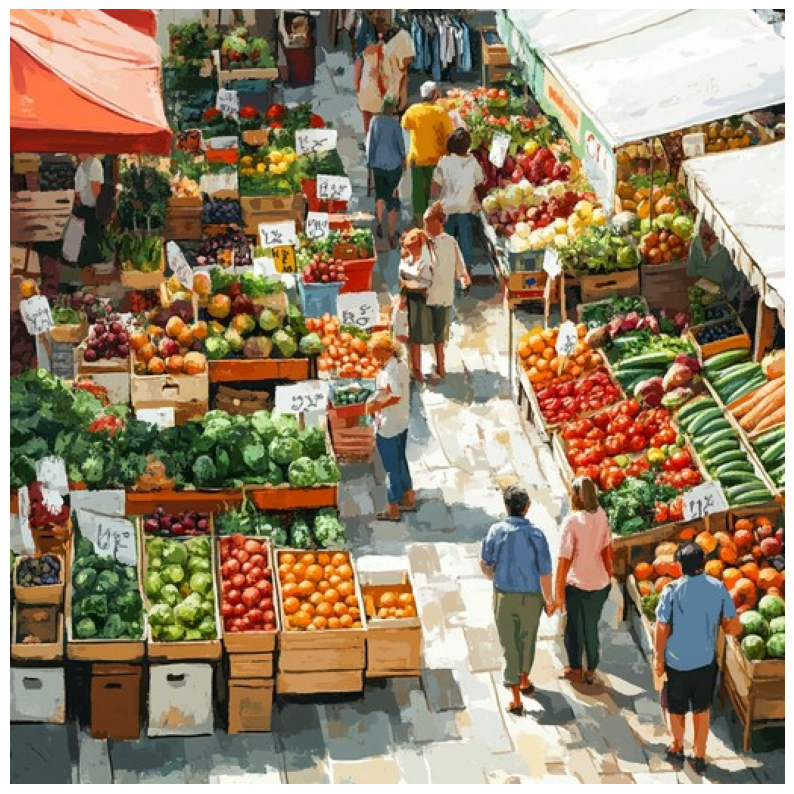

In [42]:
image_np = load_image_into_numpy_array(IMAGES_FOR_TEST[image_dropdown.value])

plt.figure(figsize=(10,20))
plt.imshow(image_np[0])
plt.axis("off")
plt.show()

### Performing the inference on the selected image

We will be using the TF hub's loaded model for inference

In [43]:
# Just pass the image(in numpy format) to the loaded TF hub model
results = hub_model(image_np)

results

{'detection_multiclass_scores': <tf.Tensor: shape=(1, 300, 91), dtype=float32, numpy=
 array([[[3.1287789e-03, 9.9663144e-01, 2.1455498e-06, ...,
          4.6317342e-05, 3.7822980e-07, 8.4124525e-07],
         [9.9804820e-03, 9.8987740e-01, 1.9440145e-06, ...,
          4.8776319e-06, 4.7354706e-07, 7.3544794e-07],
         [1.2405929e-02, 9.8741895e-01, 3.0449723e-06, ...,
          3.8117701e-06, 4.5654227e-07, 5.1061551e-07],
         ...,
         [9.3191391e-01, 4.9761161e-02, 1.7288903e-05, ...,
          9.1490353e-04, 4.2511347e-06, 5.6815829e-06],
         [9.5353729e-01, 4.7340651e-05, 4.8901006e-07, ...,
          8.3658764e-05, 3.0666121e-07, 1.6079317e-06],
         [9.7805643e-01, 1.0321116e-04, 1.9198380e-06, ...,
          6.4234810e-05, 6.1927068e-07, 2.9451203e-06]]], dtype=float32)>,
 'detection_classes': <tf.Tensor: shape=(1, 300), dtype=float32, numpy=
 array([[ 1.,  1.,  1.,  1., 55.,  1.,  1., 28.,  1.,  1.,  1.,  1., 55.,
         28.,  1., 53., 53., 55., 53., 

In [44]:
result = {key:value.numpy() for key,value in results.items()}
print(result.keys())

dict_keys(['detection_multiclass_scores', 'detection_classes', 'num_detections', 'raw_detection_boxes', 'detection_anchor_indices', 'detection_scores', 'raw_detection_scores', 'detection_boxes'])


The above code gets the predictions on the image from the loaded model through the TensorFlow hub <br>
The different parameters predicted are listed above & are also mentioned in the documentation of the models

### Visualize the results

Here we will use the TensorFlow object detection API for drawing the bounding boxes & all this based on the predictions done by the loaded TF hub model

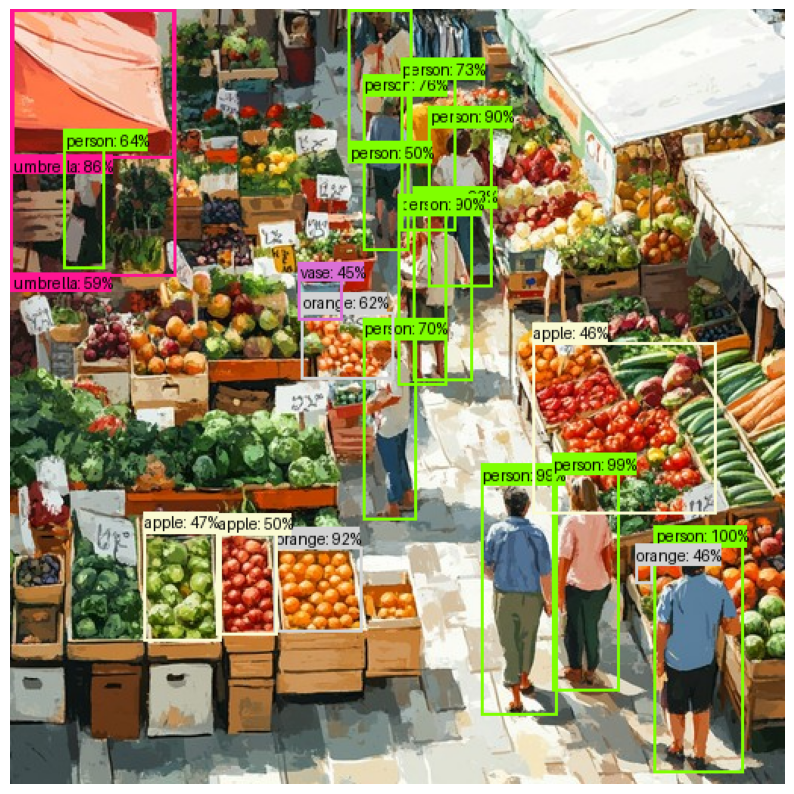

In [49]:
label_id_offset = 0
image_np_with_detections = image_np.copy()

keypoints, keypoints_scores = None, None
if 'detection_keypoints' in result:
    keypoints = result['detection_keypoints'][0]
    keypoint_scores = result['detection_keypoint_scores'][0]

viz_utils.visualize_boxes_and_labels_on_image_array(image_np_with_detections[0],
                                                    result['detection_boxes'][0],
                                                    (result['detection_classes'][0] + label_id_offset).astype(int),
                                                    result['detection_scores'][0],
                                                    category_index,
                                                    use_normalized_coordinates=True,
                                                    max_boxes_to_draw=200,
                                                    min_score_thresh=0.4,
                                                    line_thickness=2,
                                                    agnostic_mode=False,
                                                    keypoints=keypoints,
                                                    keypoint_scores=keypoint_scores,
                                                    keypoint_edges=COCO17_HUMAN_POSE_KEYPOINTS)

plt.figure(figsize=(10,20))
plt.imshow(image_np_with_detections[0])
plt.axis("off")
plt.show()